## **I. Model Evaluation: How the model performs in the real world**

- **In-sample evaluation**: tells us how ​well our model fits the data already given to train it. ​It does not give us an estimate of how ​well the trained model can predict new data -> **use the in-sample data ​or training data to train the model** (solution) | The rest of the data, called **test data**, ​is used as out-of-sample data.

- **Separating data into training and ​testing sets is an important part of model evaluation.**. For example, we can use 70% of the data for training. ​We then use 30% for testing.

- We use **training set** to build ​a model and discover predictive relationships. ​We then use a **testing set** to evaluate model performance. 
> *When we have completed testing our model, ​we should use all the data to train the model.*

- **To split data**:
```
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size = 0.3, random_state = 0)
```
- `with x_data`: features or independent variables
- `y_data`: dataset target: df['price']
- `x_train`, `y_train`: parts of available data as **training set**
- `x_test`, `y_test`: parts of available data as **testing set**
- `test_size`: % of the data for **training** (0.3 = 30% here)
- `random_state`: number generator used for random sampling (here is 0) 



---
## **II. Generalization Performance**
- **Generalization error**: is a measure of how well ​our data does a predicting previously unseen data. The error we obtain using ​our testing data is an approximation of this error. 

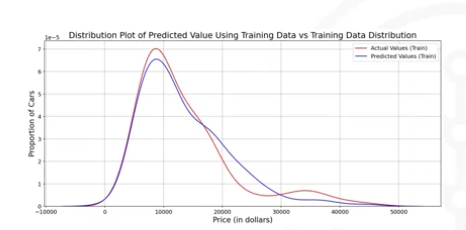
> pic 1. using training data vs training data distribution

`Actual: red | Predicted: blue | We see the distributions are somewhat similar. `

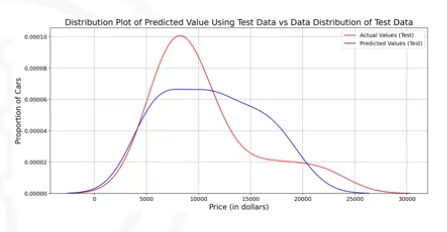
> pic 2. using testing data vs data distribution of Test Data

`If we generate the same plot using the test data, ​we see the distributions are relatively different. ​The difference is due to ​a generalization error and ​represents what we see in the real world. ​`

---

## **III. Training Data Problems**
- **If we use fewer data points to ​train the model and more to test the model, ​the accuracy of the generalization ​performance will be less, ​but the model will have good precision.**

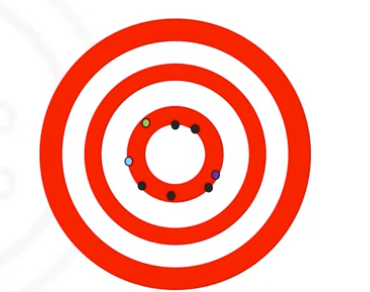
> pic1. more training data (increase performance, less precision)

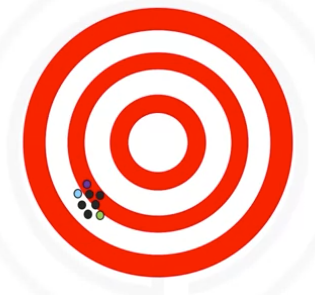
> pic2. less training data (less performance, more precision)

---

## **IV. Solutions: Cross validation. ​One of the most common out-of-sample evaluation metrics**

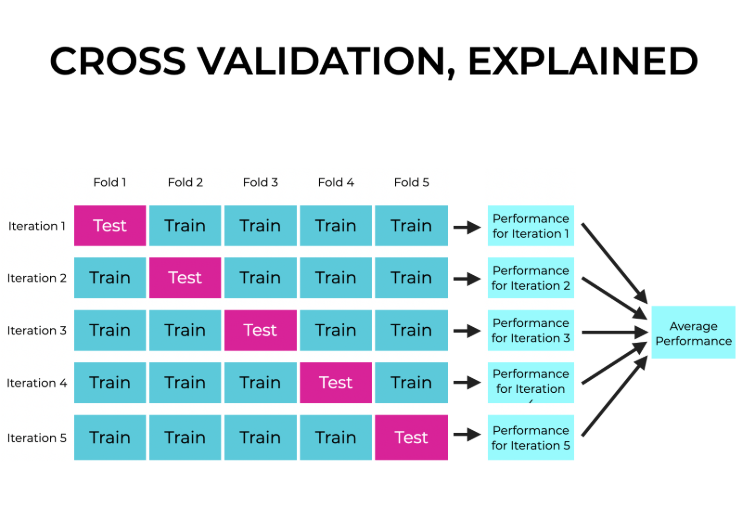

- **cross_val_score()**:
```
from sklearn.model_selection import cross_val_score

scores = cross_val_score(lr, x_data, y_data, cv = 3)

np.mean(scores)

# 'lr' here is the first input parameter, which is the type of the model
# x_data: the predictor variable data
# y_data: the target variable data
# cv = 3: numbers of partitions with the cv parameter (cv = 3 means the data set is split into 3 equal partitions)
# np.mean(scores): We can average the result together to estimate ​out-of-sample R^2 using the mean function in NumPy. 
```

- **cross_val_predict()**:
```
from sklearn.model_selection import cross_val_predict
yhat = cross_val_predict(lr2e, x_data, y_data, cv = 3)


---
## **V. Overfitting, Underfitting, Model Selection**

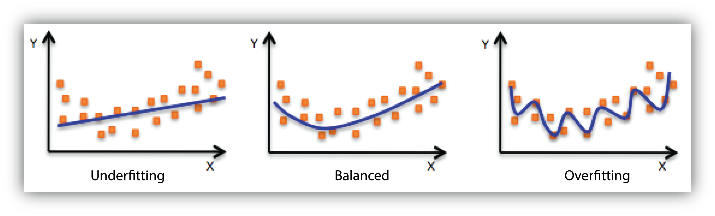
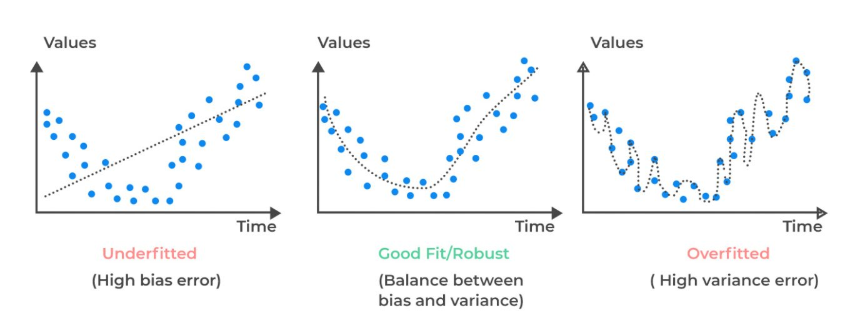
## 1. **The Concepts of Model Fit**
* **Underfitting:** Occurs when a model is **too simple to fit the data properly** (e.g., using a straight linear function for curved data). It lacks the complexity to capture the underlying trend, resulting in many errors.
* **Overfitting:** Occurs when a model is **too flexible** (e.g., a 16th-order polynomial). Instead of estimating the true underlying function, **it memorizes the training data and fits the random noise**. It typically oscillates wildly and performs poorly on new, unseen data, especially in regions with little training data.
* **Ideal Fit:** A model that **perfectly balances complexity, capturing the true function without tracking random noise** (e.g., an 8th-order polynomial in the specific video example).

## 2. **Evaluating Model Order Using MSE**
* **Training Error:** Continuously decreases as the order of the polynomial increases.
* **Testing (Validation) Error:** Decreases initially as the model improves, hits a minimum (the optimal order), and then sharply increases as the model begins to overfit. 
* **Model Selection Rule:** Always select the polynomial order that minimizes the *test error*.

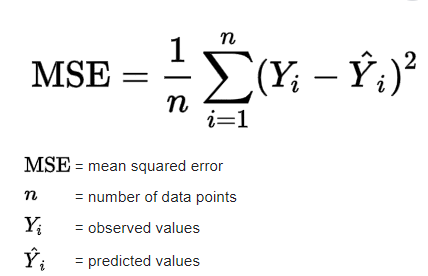

## 3. **Sources of Error**
* **Irreducible Error:** Even with the perfect polynomial order, errors will still exist due to random, unpredictable noise in the data.
* **Incorrect Assumptions:** The data might not stem from a polynomial function at all (e.g., it might be a sine wave), making polynomial regression a poor choice regardless of the order.

## 4. **Selecting Optimal Order using R-squared in Python**
* **Method:** Loop through different polynomial orders, fit the model on the training data, and calculate the $R^2$ score on the testing data.
* **Indicator:** The optimal order produces the highest $R^2$ value (closest to 1). A sudden, drastic decrease in $R^2$ (often turning deeply negative) validates that overfitting has occurred.
* **Implementation Steps:**
  1. Create an empty list to store $R^2$ values.
  2. Iterate through a list of polynomial degrees.
  3. Use `PolynomialFeatures` to transform both training and testing data.
  4. Fit the `LinearRegression` model using the transformed training data.
  5. Calculate $R^2$ using the transformed test data and append to the list.

---
## **VI. Lasso and Ridge regression**
> https://thaddeus-segura.com/lasso-ridge/

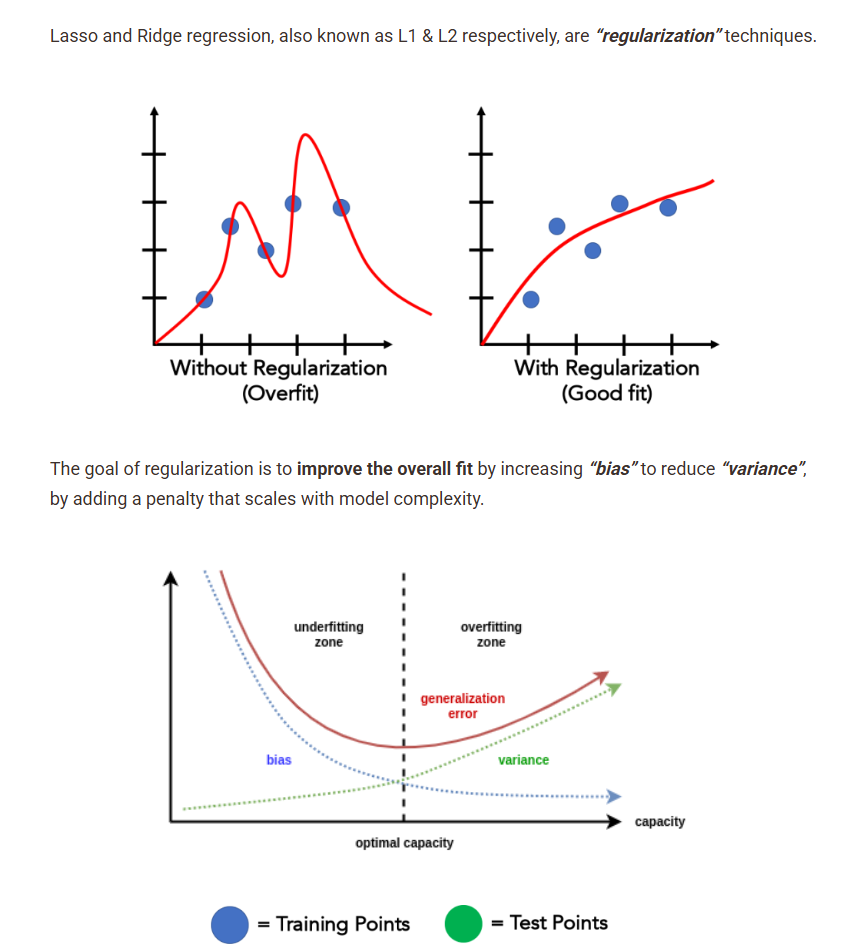
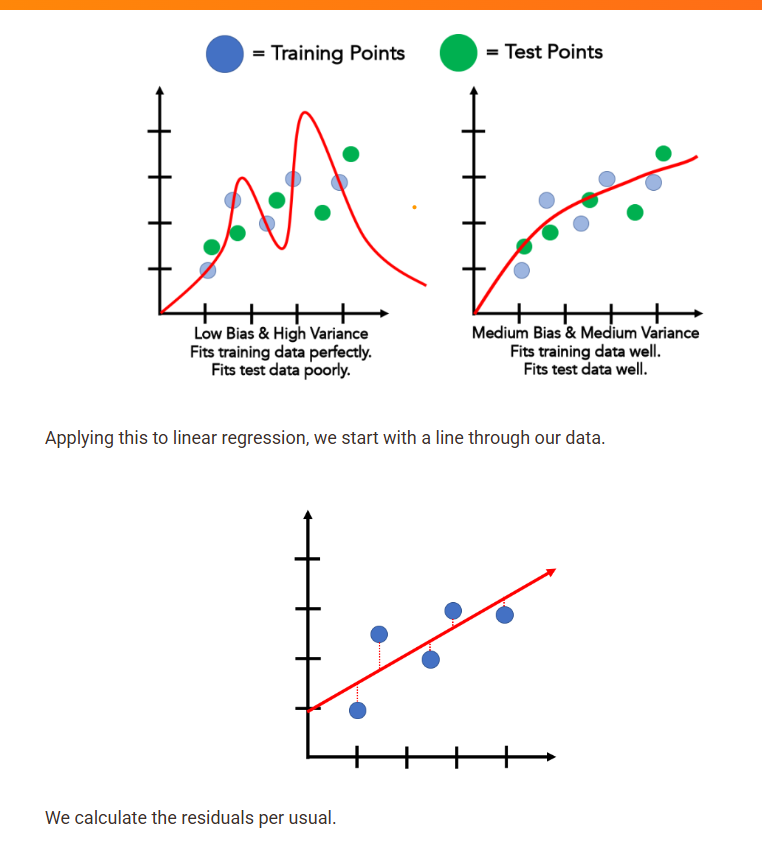
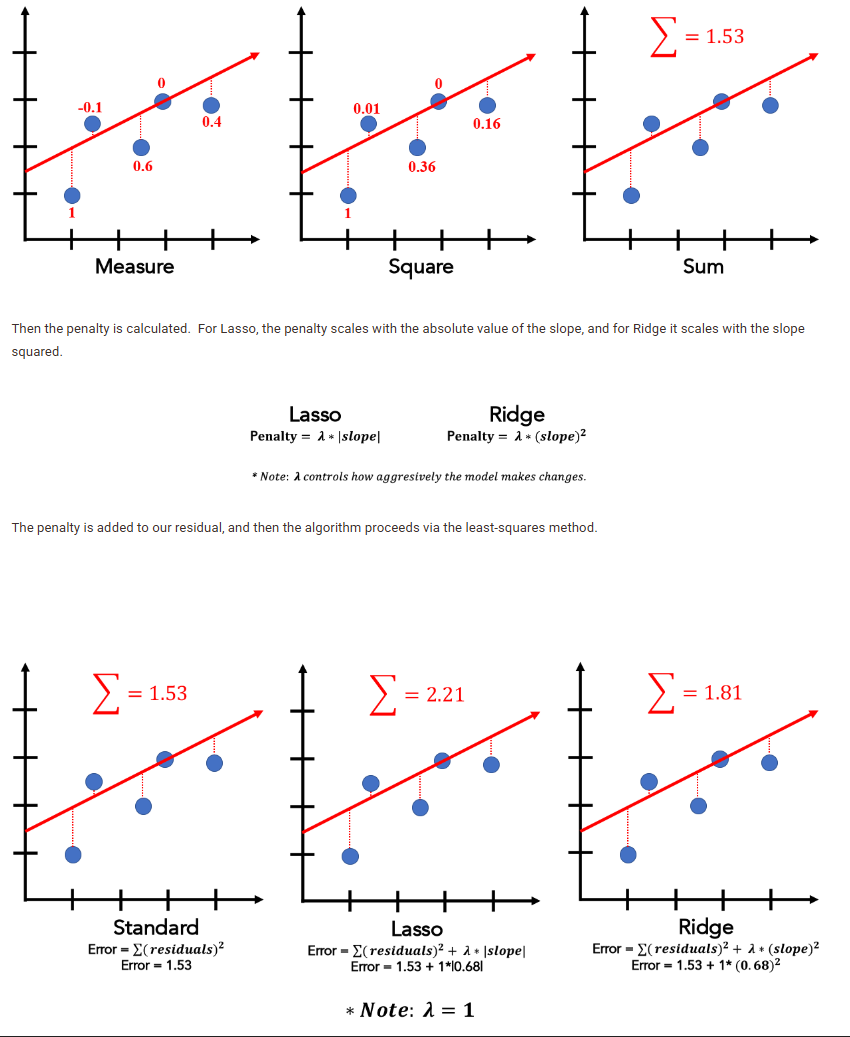
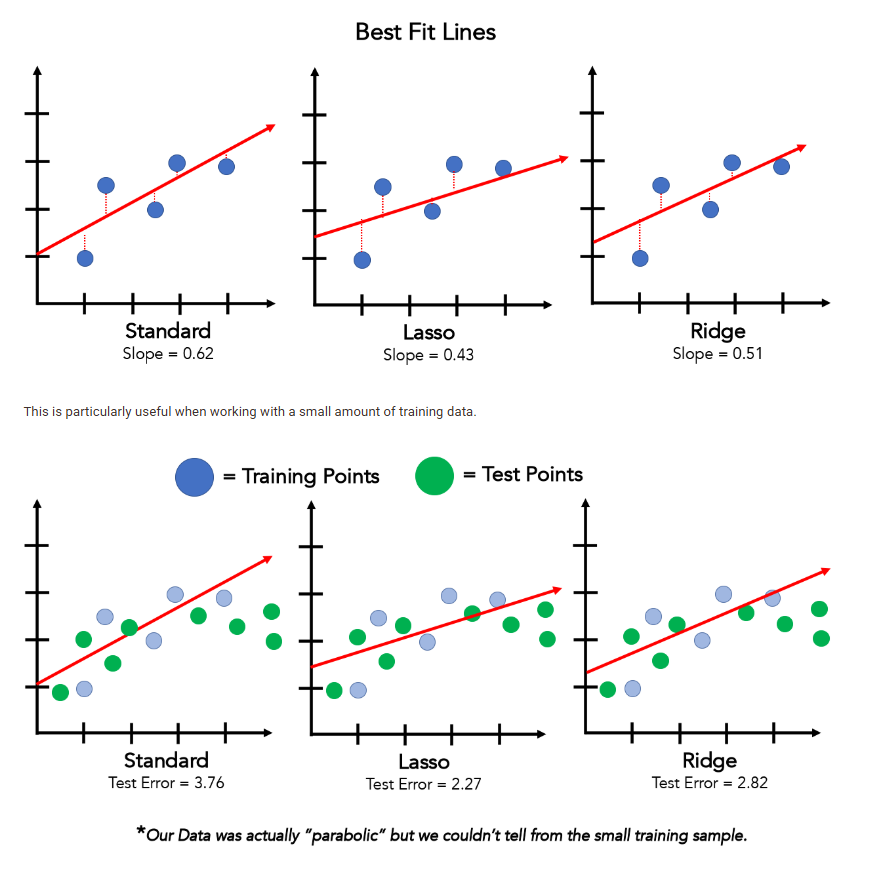
> the higher the 'Test error' point, the lower the precision is